# CS-4063 Assignment 2: BBC Urdu NLP Pipeline
## Neural NLP with PyTorch from Scratch

**ID:** i23-2607  


This notebook implements:
- Part 1: Word Embeddings (TF-IDF, PPMI, Word2Vec)
- Part 2: BiLSTM for POS Tagging & NER
- Part 3: Transformer for Topic Classification



---
## Setup and Imports

In [15]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import json
import math
import os
from collections import Counter
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

# Create directories
os.makedirs('embeddings', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")
print("\nSetup complete!")

PyTorch version: 2.10.0+cu128
Device: cuda

Setup complete!


---
## Part 1: Word Embeddings (TF-IDF, PPMI, Word2Vec)

In [16]:
# ============================================================================
# UTILITY FUNCTIONS (from utils.py)
# ============================================================================

def load_data(filepath):
    """Read cleaned.txt line by line and return list of documents"""
    if not os.path.exists(filepath):
        print(f"Error: File {filepath} not found")
        return []

    documents = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                documents.append(line)

    print(f"Loaded {len(documents)} documents from {filepath}")
    return documents


def load_metadata(filepath):
    """Load metadata JSON file"""
    with open(filepath, 'r', encoding='utf-8') as f:
        metadata = json.load(f)
    print(f"Loaded metadata for {len(metadata)} documents")
    return metadata


def save_numpy(array, filename):
    """Save numpy array to .npy file"""
    np.save(filename, array)
    print(f"Saved {array.shape} array to {filename}")


def load_numpy(filename):
    """Load numpy array from .npy file"""
    if not os.path.exists(filename):
        print(f"Error: File {filename} not found")
        return None
    array = np.load(filename)
    print(f"Loaded array from {filename} with shape {array.shape}")
    return array


def get_top_vocab(documents, vocab_size=5000):
    """Count word frequencies and return top vocab_size words"""
    word_counts = Counter()
    for doc in documents:
        words = doc.split()
        word_counts.update(words)

    top_words = [word for word, count in word_counts.most_common(vocab_size)]
    print(f"Created vocabulary of {len(top_words)} words")
    return top_words


def create_word_to_idx(vocab):
    """Create word to index and index to word mappings"""
    word_to_idx = {word: idx for idx, word in enumerate(vocab)}
    idx_to_word = {idx: word for word, idx in word_to_idx.items()}

    # Save word2idx as JSON for downstream tasks
    with open("embeddings/word2idx.json", "w", encoding="utf-8") as f:
        json.dump(word_to_idx, f, ensure_ascii=False)

    print(f"Created mappings for {len(vocab)} words")
    print(f"Saved word2idx.json")
    return word_to_idx, idx_to_word

print("Utility functions loaded.")

Utility functions loaded.


In [17]:
# ============================================================================
# TF-IDF IMPLEMENTATION
# ============================================================================

def build_term_document_matrix(documents, vocab):
    """Build term-document matrix by counting word occurrences"""
    print("Building term-document matrix...")

    word_to_idx = {word: idx for idx, word in enumerate(vocab)}
    term_doc_matrix = np.zeros((len(documents), len(vocab)))

    for doc_idx, doc in enumerate(documents):
        words = doc.split()
        for word in words:
            if word in word_to_idx:
                term_doc_matrix[doc_idx, word_to_idx[word]] += 1

    print(f"Term-document matrix shape: {term_doc_matrix.shape}")
    return term_doc_matrix


def compute_tfidf(term_doc_matrix):
    """Compute TF-IDF from term-document matrix"""
    print("Computing TF-IDF...")

    num_docs, vocab_size = term_doc_matrix.shape
    tfidf_matrix = np.zeros((num_docs, vocab_size))

    doc_freq = np.sum(term_doc_matrix > 0, axis=0)
    idf_values = np.log(num_docs / (1 + doc_freq))

    for doc_idx in range(num_docs):
        word_counts = term_doc_matrix[doc_idx, :]
        doc_length = np.sum(word_counts)

        if doc_length > 0:
            tf_values = word_counts / doc_length
            tfidf_matrix[doc_idx, :] = tf_values * idf_values

    print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
    print(f"  Min: {tfidf_matrix.min():.6f}, Max: {tfidf_matrix.max():.6f}, Mean: {tfidf_matrix.mean():.6f}")
    return tfidf_matrix

print("TF-IDF functions loaded.")

TF-IDF functions loaded.


In [18]:
# ============================================================================
# PPMI IMPLEMENTATION
# ============================================================================

def build_cooccurrence_matrix(documents, vocab, window_size=5):
    """Build co-occurrence matrix from full corpus"""
    print(f"Building co-occurrence matrix (window_size={window_size}) on FULL CORPUS...")

    word_to_idx = {word: idx for idx, word in enumerate(vocab)}
    cooccurrence_matrix = np.zeros((len(vocab), len(vocab)))

    total_pairs = 0

    for doc_idx, doc in enumerate(documents):
        if (doc_idx + 1) % 1000 == 0:
            print(f"  Document {doc_idx + 1} / {len(documents)}")

        words = doc.split()

        for i, word in enumerate(words):
            if word not in word_to_idx:
                continue

            word_idx = word_to_idx[word]
            start = max(0, i - window_size)
            end = min(len(words), i + window_size + 1)

            for j in range(start, end):
                if i != j and words[j] in word_to_idx:
                    context_idx = word_to_idx[words[j]]
                    cooccurrence_matrix[word_idx][context_idx] += 1
                    total_pairs += 1

    print(f"Co-occurrence matrix shape: {cooccurrence_matrix.shape}")
    print(f"  Total co-occurrence pairs: {total_pairs:,}")
    return cooccurrence_matrix


def compute_ppmi(cooccurrence_matrix):
    """Compute PPMI from co-occurrence matrix"""
    print("Computing PPMI...")

    vocab_size = cooccurrence_matrix.shape[0]
    total_pairs = np.sum(cooccurrence_matrix)

    if total_pairs == 0:
        print("Warning: No co-occurrence pairs found!")
        return np.zeros_like(cooccurrence_matrix)

    # Probabilities
    p_w1_w2 = cooccurrence_matrix / total_pairs
    p_w1 = np.sum(cooccurrence_matrix, axis=1) / total_pairs
    p_w2 = np.sum(cooccurrence_matrix, axis=0) / total_pairs

    # PPMI
    ppmi_matrix = np.zeros((vocab_size, vocab_size))

    for i in range(vocab_size):
        if (i + 1) % 1000 == 0:
            print(f"  Processing word {i + 1} / {vocab_size}")

        for j in range(vocab_size):
            if cooccurrence_matrix[i][j] > 0 and p_w1[i] > 0 and p_w2[j] > 0:
                pmi = np.log2(p_w1_w2[i][j] / (p_w1[i] * p_w2[j]))
                ppmi_matrix[i][j] = max(0, pmi)

    print(f"PPMI matrix shape: {ppmi_matrix.shape}")
    print(f"  Non-zero entries: {np.count_nonzero(ppmi_matrix):,}")
    print(f"  Max PPMI value: {ppmi_matrix.max():.4f}")
    return ppmi_matrix

print("PPMI functions loaded.")

PPMI functions loaded.


In [19]:
# ============================================================================
# WORD2VEC SKIP-GRAM IMPLEMENTATION
# ============================================================================

class Word2VecSkipGram:
    """Word2Vec Skip-gram with negative sampling"""

    def __init__(self, vocab_size, embedding_dim=100, window_size=5, negative_samples=10):
        """
        Args:
            embedding_dim: d = 100 (from spec)
            window_size: k = 5 (from spec)
            negative_samples: K = 10 (from spec)
            learning_rate: η = 0.001 (from spec)
        """
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.window_size = window_size
        self.negative_samples = negative_samples

        # Initialize embeddings
        self.V = np.random.randn(vocab_size, embedding_dim) * 0.01
        self.U = np.random.randn(vocab_size, embedding_dim) * 0.01
        self.learning_rate = 0.001  # η = 0.001 from spec (Adam)

        print(f"Word2Vec initialized: vocab={vocab_size}, dim={embedding_dim}, "
              f"window={window_size}, neg_samples={negative_samples}, lr={self.learning_rate}")

    def sigmoid(self, x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

    def train(self, documents, word_to_idx, epochs=3):
        """Train Word2Vec model"""
        print(f"Building training pairs (epochs={epochs})...")

        # Build pairs
        training_pairs = []
        for doc_idx, doc in enumerate(documents):
            if (doc_idx + 1) % 1000 == 0:
                print(f"  Document {doc_idx + 1} / {len(documents)}")

            words = doc.split()
            for i, word in enumerate(words):
                if word not in word_to_idx:
                    continue

                center_idx = word_to_idx[word]
                start = max(0, i - self.window_size)
                end = min(len(words), i + self.window_size + 1)

                for j in range(start, end):
                    if j != i and j < len(words) and words[j] in word_to_idx:
                        context_idx = word_to_idx[words[j]]
                        training_pairs.append((center_idx, context_idx))

        print(f"Total training pairs: {len(training_pairs):,}")

        if len(training_pairs) == 0:
            print("ERROR: No training pairs found!")
            return

        # Noise distribution
        freq = np.zeros(self.vocab_size)
        for center, _ in training_pairs:
            freq[center] += 1

        noise_dist = freq ** 0.75
        total = noise_dist.sum()

        if total > 0:
            noise_dist /= total
        else:
            noise_dist = np.ones(self.vocab_size) / self.vocab_size

        # Training
        print(f"Training for {epochs} epochs...")

        initial_lr = self.learning_rate

        for epoch in range(epochs):
            import random
            random.shuffle(training_pairs)

            epoch_loss = 0

            for pair_idx, (center_idx, context_idx) in enumerate(training_pairs):
                # Linear learning rate decay
                progress = (epoch * len(training_pairs) + pair_idx) / (epochs * len(training_pairs))
                current_lr = initial_lr * (1.0 - progress)
                current_lr = max(current_lr, initial_lr * 0.0001)

                # Positive pair
                v_center = self.V[center_idx]
                u_context = self.U[context_idx]

                dot_prod = np.dot(v_center, u_context)
                output = self.sigmoid(dot_prod)

                loss = -np.log(output + 1e-10)

                # Gradient update
                grad = (output - 1) * u_context
                self.V[center_idx] -= current_lr * grad
                self.U[context_idx] -= current_lr * (output - 1) * v_center

                # Negative samples
                neg_samples = np.random.choice(self.vocab_size, size=self.negative_samples, p=noise_dist)

                for neg_idx in neg_samples:
                    u_neg = self.U[neg_idx]
                    dot_neg = np.dot(v_center, u_neg)
                    out_neg = self.sigmoid(dot_neg)

                    loss += -np.log(1 - out_neg + 1e-10)

                    self.V[center_idx] -= current_lr * out_neg * u_neg
                    self.U[neg_idx] -= current_lr * out_neg * v_center

                epoch_loss += loss

                if (pair_idx + 1) % 50000 == 0:
                    print(f"  Epoch {epoch+1}/{epochs}, Pair {pair_idx+1}/{len(training_pairs)}, "
                          f"Loss: {epoch_loss/(pair_idx+1):.4f}, LR: {current_lr:.6f}")

            avg_loss = epoch_loss / len(training_pairs)
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")

        print("Training complete!")

    def get_embeddings(self):
        return (self.V + self.U) / 2

print("Word2Vec functions loaded.")

Word2Vec functions loaded.


In [20]:
# ============================================================================
# EVALUATION FUNCTIONS
# ============================================================================

def get_nearest_neighbors(embeddings, word_idx, vocab, k=5):
    """Find k nearest neighbors using cosine similarity"""
    word_vec = embeddings[word_idx]
    similarities = []

    for i in range(len(embeddings)):
        if i != word_idx:
            other_vec = embeddings[i]

            norm1 = np.linalg.norm(word_vec)
            norm2 = np.linalg.norm(other_vec)

            if norm1 > 0 and norm2 > 0:
                sim = np.dot(word_vec, other_vec) / (norm1 * norm2)
                similarities.append((i, sim))

    similarities.sort(key=lambda x: x[1], reverse=True)
    return [(vocab[idx], sim) for idx, sim in similarities[:k]]

print("Evaluation functions loaded.")

Evaluation functions loaded.


In [21]:
# ============================================================================
# PART 1: EMBEDDINGS EXECUTION
# ============================================================================

print("\n" + "="*80)
print("PART 1: WORD EMBEDDINGS (TF-IDF, PPMI, Word2Vec)")
print("="*80)

# Load data
print("\n[Loading Data]")
documents = load_data("data/cleaned.txt")
metadata = load_metadata("data/metadata.json")
vocab = get_top_vocab(documents, vocab_size=5000)
word_to_idx, idx_to_word = create_word_to_idx(vocab)

print(f"\nData Summary:")
print(f"  Documents: {len(documents)}")
print(f"  Vocabulary size: {len(vocab)}")
print(f"  Avg doc length: {np.mean([len(d.split()) for d in documents]):.1f} words")


PART 1: WORD EMBEDDINGS (TF-IDF, PPMI, Word2Vec)

[Loading Data]
Loaded 11168 documents from data/cleaned.txt
Loaded metadata for 200 documents
Created vocabulary of 5000 words
Created mappings for 5000 words
Saved word2idx.json

Data Summary:
  Documents: 11168
  Vocabulary size: 5000
  Avg doc length: 26.1 words


In [22]:
# TF-IDF
print("\n" + "-"*80)
print("1. TF-IDF Embeddings")
print("-"*80)

term_doc_matrix = build_term_document_matrix(documents, vocab)
tfidf_matrix = compute_tfidf(term_doc_matrix)
save_numpy(tfidf_matrix, "embeddings/tfidf_matrix.npy")

# Show sample TF-IDF nearest neighbors
print("\nSample TF-IDF Nearest Neighbors:")
test_word = vocab[0]
test_idx = 0
neighbors = get_nearest_neighbors(tfidf_matrix, test_idx, vocab, k=5)
print(f"  '{test_word}': {', '.join([f'{w}({s:.3f})' for w, s in neighbors])}")



--------------------------------------------------------------------------------
1. TF-IDF Embeddings
--------------------------------------------------------------------------------
Building term-document matrix...
Term-document matrix shape: (11168, 5000)
Computing TF-IDF...
TF-IDF matrix shape: (11168, 5000)
  Min: 0.000000, Max: 7.711370, Mean: 0.000687
Saved (11168, 5000) array to embeddings/tfidf_matrix.npy

Sample TF-IDF Nearest Neighbors:
  'کے': 


In [23]:
# PPMI
print("\n" + "-"*80)
print("2. PPMI Embeddings (Full Corpus)")
print("-"*80)

cooccurrence = build_cooccurrence_matrix(documents, vocab, window_size=5)
ppmi_matrix = compute_ppmi(cooccurrence)
save_numpy(ppmi_matrix, "embeddings/ppmi_matrix.npy")

# Show sample PPMI nearest neighbors
print("\nSample PPMI Nearest Neighbors:")
neighbors = get_nearest_neighbors(ppmi_matrix, test_idx, vocab, k=5)
print(f"  '{test_word}': {', '.join([f'{w}({s:.3f})' for w, s in neighbors])}")



--------------------------------------------------------------------------------
2. PPMI Embeddings (Full Corpus)
--------------------------------------------------------------------------------
Building co-occurrence matrix (window_size=5) on FULL CORPUS...
  Document 1000 / 11168
  Document 2000 / 11168
  Document 3000 / 11168
  Document 4000 / 11168
  Document 5000 / 11168
  Document 6000 / 11168
  Document 7000 / 11168
  Document 8000 / 11168
  Document 9000 / 11168
  Document 10000 / 11168
  Document 11000 / 11168
Co-occurrence matrix shape: (5000, 5000)
  Total co-occurrence pairs: 2,342,852
Computing PPMI...
  Processing word 1000 / 5000
  Processing word 2000 / 5000
  Processing word 3000 / 5000
  Processing word 4000 / 5000
  Processing word 5000 / 5000
PPMI matrix shape: (5000, 5000)
  Non-zero entries: 600,363
  Max PPMI value: 14.0388
Saved (5000, 5000) array to embeddings/ppmi_matrix.npy

Sample PPMI Nearest Neighbors:
  'کے': مطابق(0.398), لیے(0.379), میں(0.349), نے(0.34

In [24]:
# Word2Vec
print("\n" + "-"*80)
print("3. Word2Vec Skip-gram Embeddings")
print("-"*80)
print("Hyperparameters (from spec):")
print("  d (embedding_dim) = 100")
print("  k (window_size) = 5")
print("  K (negative_samples) = 10")
print("  η (learning_rate) = 0.001")
print()

w2v_model = Word2VecSkipGram(
    vocab_size=len(vocab),
    embedding_dim=100,  # d=100 from spec
    window_size=5,      # k=5 from spec
    negative_samples=10 # K=10 from spec
)

w2v_model.train(documents, word_to_idx, epochs=2)

w2v_embeddings = w2v_model.get_embeddings()
save_numpy(w2v_embeddings, "embeddings/embeddings_w2v.npy")

# Show sample Word2Vec nearest neighbors
print("\nSample Word2Vec Nearest Neighbors:")
neighbors = get_nearest_neighbors(w2v_embeddings, test_idx, vocab, k=5)
print(f"  '{test_word}': {', '.join([f'{w}({s:.3f})' for w, s in neighbors])}")

print("\n" + "="*80)
print("PART 1 COMPLETE: All embeddings saved")
print("="*80)


--------------------------------------------------------------------------------
3. Word2Vec Skip-gram Embeddings
--------------------------------------------------------------------------------
Hyperparameters (from spec):
  d (embedding_dim) = 100
  k (window_size) = 5
  K (negative_samples) = 10
  η (learning_rate) = 0.001

Word2Vec initialized: vocab=5000, dim=100, window=5, neg_samples=10, lr=0.001
Building training pairs (epochs=2)...
  Document 1000 / 11168
  Document 2000 / 11168
  Document 3000 / 11168
  Document 4000 / 11168
  Document 5000 / 11168
  Document 6000 / 11168
  Document 7000 / 11168
  Document 8000 / 11168
  Document 9000 / 11168
  Document 10000 / 11168
  Document 11000 / 11168
Total training pairs: 2,342,852
Training for 2 epochs...
  Epoch 1/2, Pair 50000/2342852, Loss: 7.6245, LR: 0.000989
  Epoch 1/2, Pair 100000/2342852, Loss: 7.6242, LR: 0.000979
  Epoch 1/2, Pair 150000/2342852, Loss: 7.6232, LR: 0.000968
  Epoch 1/2, Pair 200000/2342852, Loss: 7.6196, L

---
## Part 2: BiLSTM for Sequence Labeling (POS Tagging & NER)

In [25]:
# ============================================================================
# DATASET PREPARATION (POS Lexicon & NER Gazetteer)
# ============================================================================

POS_LEXICON = {
    # NOUN
    "ملک": "NOUN", "شہر": "NOUN", "حکومت": "NOUN", "وزیر": "NOUN", "صدر": "NOUN",
    "پاکستان": "NOUN", "انڈیا": "NOUN", "امریکہ": "NOUN", "چین": "NOUN", "فوج": "NOUN",
    "عدالت": "NOUN", "پارلیمنٹ": "NOUN", "بچہ": "NOUN", "اسکول": "NOUN", "ڈاکٹر": "NOUN",
    "انجینئر": "NOUN", "وکیل": "NOUN", "پولیس": "NOUN", "اسپتال": "NOUN", "بینک": "NOUN",
    "کتاب": "NOUN", "قلم": "NOUN", "گھر": "NOUN", "دفتر": "NOUN", "یونیورسٹی": "NOUN",
    "طالب": "NOUN", "استاد": "NOUN", "دوست": "NOUN", "والد": "NOUN", "والدہ": "NOUN",
    "بھائی": "NOUN", "بہن": "NOUN", "لڑکا": "NOUN", "لڑکی": "NOUN", "عورت": "NOUN",
    "آدمی": "NOUN", "لوگ": "NOUN", "سال": "NOUN", "دن": "NOUN", "رات": "NOUN",
    "مہینہ": "NOUN", "ہفتہ": "NOUN", "صبح": "NOUN", "شام": "NOUN", "رپورٹ": "NOUN",
    "خبر": "NOUN", "میڈیا": "NOUN", "ٹی وی": "NOUN", "ریڈیو": "NOUN", "انٹرنیٹ": "NOUN",
    # VERB
    "ہے": "VERB", "ہیں": "VERB", "ہو": "VERB", "ہوں": "VERB", "تھا": "VERB", "تھے": "VERB",
    "تھی": "VERB", "تھیں": "VERB", "کیا": "VERB", "کیے": "VERB", "کی": "VERB", "کرتا": "VERB",
    "کرتے": "VERB", "کرتی": "VERB", "کریں": "VERB", "جاتا": "VERB", "جاتے": "VERB",
    "جاتی": "VERB", "جائیں": "VERB", "آتا": "VERB", "آتے": "VERB", "آتی": "VERB",
    "آئیں": "VERB", "دیتا": "VERB", "دیتے": "VERB", "دیتی": "VERB", "دیں": "VERB",
    "لیتا": "VERB", "لیتے": "VERB", "لیتی": "VERB", "لیں": "VERB", "کہتا": "VERB",
    "کہتے": "VERB", "کہتی": "VERB", "کہیں": "VERB", "دیکھتا": "VERB", "دیکھتے": "VERB",
    "دیکھتی": "VERB", "دیکھیں": "VERB", "سنتا": "VERB", "سنتے": "VERB", "سنتی": "VERB",
    "سنیں": "VERB", "رہتا": "VERB", "رہتے": "VERB", "رہتی": "VERB", "رہیں": "VERB",
    "بولتا": "VERB", "بولتے": "VERB", "بولتی": "VERB", "ہوتا": "VERB",
    # ADJ
    "بڑا": "ADJ", "بڑے": "ADJ", "بڑی": "ADJ", "چھوٹا": "ADJ", "چھوٹے": "ADJ", "چھوٹی": "ADJ",
    "اچھا": "ADJ", "اچھے": "ADJ", "اچھی": "ADJ", "برا": "ADJ", "برے": "ADJ", "بری": "ADJ",
    "نیا": "ADJ", "نئے": "ADJ", "نئی": "ADJ", "پرانا": "ADJ", "پرانے": "ADJ", "پرانی": "ADJ",
    "خوبصورت": "ADJ", "خوش": "ADJ", "غمگین": "ADJ", "تیز": "ADJ", "سست": "ADJ",
    "گرم": "ADJ", "ٹھنڈا": "ADJ", "سفید": "ADJ", "کالا": "ADJ", "لال": "ADJ", "سبز": "ADJ",
    # ADV, PRON, DET, CONJ, POST, NUM, PUNC
    "بہت": "ADV", "کافی": "ADV", "زیادہ": "ADV", "کم": "ADV", "جلدی": "ADV", "آہستہ": "ADV",
    "اب": "ADV", "پھر": "ADV", "ہمیشہ": "ADV", "کل": "ADV", "آج": "ADV",
    "میں": "PRON", "تم": "PRON", "آپ": "PRON", "وہ": "PRON", "ہم": "PRON", "یہ": "PRON",
    "ایک": "DET", "ہر": "DET", "اس": "DET", "ان": "DET",
    "اور": "CONJ", "لیکن": "CONJ", "اگر": "CONJ", "تو": "CONJ",
    "پر": "POST", "سے": "POST", "کو": "POST", "کے": "POST", "کی": "POST",
    "کا": "POST", "نے": "POST", "تک": "POST",
    "دو": "NUM", "تین": "NUM", "چار": "NUM", "دس": "NUM",
    "۔": "PUNC", "،": "PUNC", "?": "PUNC", "!": "PUNC",
}

NER_GAZETTEER = {
    # Persons
    "بابر": ("B-PER", "Babar Azam"), "رضوان": ("B-PER", "Mohammad Rizwan"), "شاداب": ("B-PER", "Shadab Khan"),
    "فخر": ("B-PER", "Fakhar Zaman"), "حسن": ("B-PER", "Hasan Ali"), "شاہین": ("B-PER", "Shaheen Afridi"),
    "سرفراز": ("B-PER", "Sarfaraz Ahmed"), "عامر": ("B-PER", "Mohammad Amir"), "عثمان": ("B-PER", "Usman Khawaja"),
    "فہد": ("B-PER", "Fahad Mustafa"), "ہمایوں": ("B-PER", "Humayun Saeed"), "ماہرہ": ("B-PER", "Mahira Khan"),
    "اقبال": ("B-PER", "Allama Iqbal"), "فیض": ("B-PER", "Faiz Ahmed Faiz"), "غالب": ("B-PER", "Mirza Ghalib"),
    # Locations
    "پاکستان": ("B-LOC", "Pakistan"), "کراچی": ("B-LOC", "Karachi"), "لاہور": ("B-LOC", "Lahore"),
    "اسلام": ("B-LOC", "Islamabad"), "آباد": ("I-LOC", "Islamabad"), "پشاور": ("B-LOC", "Peshawar"),
    "کوئٹہ": ("B-LOC", "Quetta"), "ملتان": ("B-LOC", "Multan"), "فیصل": ("B-LOC", "Faisalabad"),
    "راولپنڈی": ("B-LOC", "Rawalpindi"), "حیدرآباد": ("B-LOC", "Hyderabad"), "سکھر": ("B-LOC", "Sukkur"),
    "گوجرانوالہ": ("B-LOC", "Gujranwala"), "بہاولپور": ("B-LOC", "Bahawalpur"), "سرگودھا": ("B-LOC", "Sargodha"),
    "مردان": ("B-LOC", "Mardan"), "ابٹ": ("B-LOC", "Abbottabad"), "مری": ("B-LOC", "Murree"),
    "پنجاب": ("B-LOC", "Punjab"), "سندھ": ("B-LOC", "Sindh"), "خیبر": ("B-LOC", "Khyber Pakhtunkhwa"),
    "بلوچستان": ("B-LOC", "Balochistan"), "انڈیا": ("B-LOC", "India"), "امریکہ": ("B-LOC", "United States"),
    "چین": ("B-LOC", "China"),
    # Organizations
    "حکومت": ("B-ORG", "Government"), "پارلیمنٹ": ("B-ORG", "Parliament"), "عدالت": ("B-ORG", "Court"),
    "سپریم": ("B-ORG", "Supreme Court"), "کورٹ": ("I-ORG", "Court"), "فوج": ("B-ORG", "Pakistan Army"),
    "پولیس": ("B-ORG", "Police"), "کرکٹ": ("B-ORG", "Pakistan Cricket"), "بورڈ": ("I-ORG", "Board"),
    "بینک": ("B-ORG", "State Bank"), "یونیورسٹی": ("B-ORG", "University"), "اسپتال": ("B-ORG", "Hospital"),
}

class SimpleRuleTagger:
    def __init__(self, pos_lexicon, ner_gazetteer):
        self.pos_lexicon = pos_lexicon
        self.ner_gazetteer = ner_gazetteer

    def tag_pos(self, word):
        if word in self.pos_lexicon:
            return self.pos_lexicon[word]
        if any(word.endswith(e) for e in ["تا", "تے", "تی", "ہے", "ہیں", "ہو"]):
            return "VERB"
        if any(word.endswith(e) for e in ["ی", "اں", "وں"]):
            return "ADJ"
        return "NOUN"

    def tag_ner(self, word):
        if word in self.ner_gazetteer:
            return self.ner_gazetteer[word][0]
        return "O"

    def tag_sentence(self, sentence):
        words = sentence.split()
        pos_tags = [self.tag_pos(w) for w in words]
        ner_tags = [self.tag_ner(w) for w in words]
        return words, pos_tags, ner_tags


def save_conll(data, path):
    """Save annotated data to CoNLL format"""
    with open(path, 'w', encoding='utf-8') as f:
        for words, pos, ner in data:
            for w, p, n in zip(words, pos, ner):
                f.write(f"{w}\t{p}\t{n}\n")
            f.write("\n")
    print(f"Saved {len(data)} sentences to {path}")

print("Dataset functions loaded.")

Dataset functions loaded.


In [26]:
# ============================================================================
# PREPARE DATASET FOR PART 2 (POS + NER)
# ============================================================================

print("\n" + "="*80)
print("Preparing Dataset for BiLSTM Training")
print("="*80)

import random
from collections import defaultdict

# Reload documents for dataset preparation
documents = load_data("data/cleaned.txt")
metadata = load_metadata("data/metadata.json")

# Stratified sampling
topic_to_docs = defaultdict(list)
for idx, doc in enumerate(documents):
    doc_id = str(idx) if str(idx) in metadata else str(idx + 1)
    if doc_id in metadata:
        cat = metadata[doc_id].get("category", "unknown")
        topic_to_docs[cat].append((idx, doc))

top_topics = sorted(topic_to_docs.items(), key=lambda x: len(x[1]), reverse=True)[:3]
print(f"Selected top 3 topics: {[t[0] for t in top_topics]}")

selected = []
for _, docs in top_topics:
    sample_size = min(100, len(docs))
    selected.extend(random.sample(docs, sample_size))

# Fill up to 500
remaining = [(i, d) for i, d in enumerate(documents) if (i, d) not in selected]
if len(selected) < 500:
    selected.extend(random.sample(remaining, min(500 - len(selected), len(remaining))))

random.shuffle(selected)
selected = selected[:500]

print(f"Selected {len(selected)} sentences for annotation")

# Tag all sentences
tagger = SimpleRuleTagger(POS_LEXICON, NER_GAZETTEER)
annotations = [tagger.tag_sentence(doc) for _, doc in selected]

# Split: 70/15/15
random.shuffle(annotations)
n = len(annotations)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

train_data = annotations[:train_end]
val_data = annotations[train_end:val_end]
test_data = annotations[val_end:]

print(f"\nDataset Split:")
print(f"  Train: {len(train_data)} sentences")
print(f"  Val: {len(val_data)} sentences")
print(f"  Test: {len(test_data)} sentences")

# Save files
save_conll(train_data, "data/pos_train.conll")
save_conll(val_data, "data/pos_val.conll")
save_conll(test_data, "data/pos_test.conll")

save_conll(train_data, "data/ner_train.conll")
save_conll(val_data, "data/ner_val.conll")
save_conll(test_data, "data/ner_test.conll")

print("\nDataset preparation complete!")


Preparing Dataset for BiLSTM Training
Loaded 11168 documents from data/cleaned.txt
Loaded metadata for 200 documents
Selected top 3 topics: ['unknown']
Selected 500 sentences for annotation

Dataset Split:
  Train: 350 sentences
  Val: 75 sentences
  Test: 75 sentences
Saved 350 sentences to data/pos_train.conll
Saved 75 sentences to data/pos_val.conll
Saved 75 sentences to data/pos_test.conll
Saved 350 sentences to data/ner_train.conll
Saved 75 sentences to data/ner_val.conll
Saved 75 sentences to data/ner_test.conll

Dataset preparation complete!


In [27]:
# ============================================================================
# BiLSTM + CRF LAYER
# ============================================================================

class CRF(nn.Module):
    """Simple CRF layer for NER"""
    def __init__(self, num_tags):
        super().__init__()
        self.num_tags = num_tags
        self.transitions = nn.Parameter(torch.randn(num_tags, num_tags))

    def forward(self, emissions, tags, mask):
        """Compute negative log likelihood"""
        batch_size = emissions.size(0)
        seq_len = emissions.size(1)

        loss = 0
        for b in range(batch_size):
            for t in range(seq_len):
                if mask[b, t] > 0:
                    loss += emissions[b, t, tags[b, t]]

        return -loss / batch_size

    def decode(self, emissions, mask):
        """Simple greedy decoding"""
        return torch.argmax(emissions, dim=-1)


class BiLSTMTagger(nn.Module):
    """2-layer Bidirectional LSTM for Sequence Labeling"""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_tags,
                 pretrained_embeddings=None, freeze_embeddings=False, use_crf=False):
        super().__init__()
        self.use_crf = use_crf

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            pretrained_vocab_size = pretrained_embeddings.shape[0]
            if pretrained_vocab_size < vocab_size:
                extended = np.random.randn(vocab_size, embed_dim).astype(np.float32) * 0.01
                extended[:pretrained_vocab_size] = pretrained_embeddings
                self.embedding.weight.data.copy_(torch.from_numpy(extended))
            else:
                self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings[:vocab_size]))
            self.embedding.weight.requires_grad = not freeze_embeddings

        # BiLSTM: dropout=0.5 (from spec)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2,
                           bidirectional=True, batch_first=True, dropout=0.5)

        # Classifier
        self.classifier = nn.Linear(hidden_dim * 2, num_tags)

        # CRF
        if use_crf:
            self.crf = CRF(num_tags)

    def forward(self, x, lengths):
        """Forward pass"""
        emb = self.embedding(x)
        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        lstm_out, _ = self.lstm(packed)
        lstm_out, _ = pad_packed_sequence(lstm_out, batch_first=True)
        logits = self.classifier(lstm_out)
        return logits

    def loss(self, x, y, lengths):
        """Compute loss"""
        logits = self.forward(x, lengths)

        if self.use_crf:
            mask = torch.arange(x.size(1), device=x.device).unsqueeze(0) < lengths.unsqueeze(1)
            mask = mask.float()
            y_crf = y.clone()
            y_crf[y == -100] = 0
            return self.crf(logits, y_crf, mask)
        else:
            loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
            return loss_fn(logits.view(-1, logits.size(-1)), y.view(-1))

    def predict(self, x, lengths):
        """Predict tags"""
        logits = self.forward(x, lengths)
        if self.use_crf:
            mask = torch.arange(x.size(1), device=x.device).unsqueeze(0) < lengths.unsqueeze(1)
            return self.crf.decode(logits, mask)
        else:
            return torch.argmax(logits, dim=-1)

print("BiLSTM and CRF classes loaded.")


BiLSTM and CRF classes loaded.


In [28]:
# ============================================================================
# SEQUENCE DATASET
# ============================================================================

class SequenceDataset(Dataset):
    """Dataset for POS/NER tagging from CoNLL format"""
    def __init__(self, filepath, word2idx, tag2idx, task='pos'):
        self.sentences = []
        self.labels = []

        with open(filepath, 'r', encoding='utf-8') as f:
            words, tags = [], []
            for line in f:
                line = line.strip()
                if not line:
                    if words:
                        word_ids = [word2idx.get(w, word2idx.get('<UNK>', 0)) for w in words]
                        tag_ids = [tag2idx.get(t, 0) for t in tags]
                        self.sentences.append(word_ids)
                        self.labels.append(tag_ids)
                        words, tags = [], []
                else:
                    parts = line.split('\t')
                    if len(parts) >= 2:
                        words.append(parts[0])
                        tags.append(parts[1] if task == 'pos' else (parts[2] if len(parts) >= 3 else 'O'))

        print(f"  Loaded {len(self.sentences)} sentences from {filepath}")

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        return torch.tensor(self.sentences[idx]), torch.tensor(self.labels[idx])


def collate_fn(batch):
    """Collate function for padding sequences"""
    sentences, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in sentences])
    sentences = nn.utils.rnn.pad_sequence(sentences, batch_first=True, padding_value=0)
    labels = nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value=-100)
    return sentences, labels, lengths

print("SequenceDataset class loaded.")


SequenceDataset class loaded.


In [29]:
# ============================================================================
# BILSTM TRAINING FUNCTION
# ============================================================================

def train_bilstm_model(task, freeze_embeddings=False, use_crf=False):
    """
    Train BiLSTM model for POS/NER
    Hyperparameters from spec: dropout=0.5, patience=5
    """
    print(f"\n{'='*80}")
    print(f"Training {task.upper()} | Freeze={freeze_embeddings}, CRF={use_crf}")
    print(f"Hyperparameters: dropout=0.5 (embedded), patience=5")
    print(f"{'='*80}")

    # Load embeddings
    embeddings = np.load("embeddings/embeddings_w2v.npy")
    with open("embeddings/word2idx.json", 'r', encoding='utf-8') as f:
        word2idx = json.load(f)

    # Build tag vocabulary
    tag2idx = {}
    with open(f"data/{task}_train.conll", 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                parts = line.split('\t')
                tag = parts[1] if task == 'pos' else (parts[2] if len(parts) >= 3 else 'O')
                if tag not in tag2idx:
                    tag2idx[tag] = len(tag2idx)

    idx2tag = {v: k for k, v in tag2idx.items()}
    print(f"Vocabulary: {len(word2idx)}, Tags: {len(tag2idx)}")

    # Load datasets
    train_ds = SequenceDataset(f"data/{task}_train.conll", word2idx, tag2idx, task)
    val_ds = SequenceDataset(f"data/{task}_val.conll", word2idx, tag2idx, task)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, collate_fn=collate_fn)

    # Create model
    embed_dim = embeddings.shape[1]
    model = BiLSTMTagger(
        vocab_size=len(word2idx),
        embed_dim=embed_dim,
        hidden_dim=256,
        num_tags=len(tag2idx),
        pretrained_embeddings=embeddings,
        freeze_embeddings=freeze_embeddings,
        use_crf=use_crf
    )

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

    # Training loop
    best_f1 = 0
    patience_counter = 0
    train_losses = []
    val_f1_scores = []

    for epoch in range(30):
        # Train
        model.train()
        total_loss = 0
        for x, y, lengths in train_loader:
            x, y, lengths = x.to(device), y.to(device), lengths.to(device)
            optimizer.zero_grad()
            loss = model.loss(x, y, lengths)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Validate
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for x, y, lengths in val_loader:
                x, y, lengths = x.to(device), y.to(device), lengths.to(device)
                preds = model.predict(x, lengths)
                for i in range(x.size(0)):
                    length = lengths[i].item()
                    all_preds.extend(preds[i, :length].cpu().numpy())
                    all_labels.extend(y[i, :length].cpu().numpy())

        val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        val_f1_scores.append(val_f1)

        print(f"Epoch {epoch+1:2d} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f}")

        # Early stopping with patience=5
        if val_f1 > best_f1:
            best_f1 = val_f1
            patience_counter = 0
            model_name = f"bilstm_{task}{'_frozen' if freeze_embeddings else ''}{'_crf' if use_crf else ''}.pt"
            torch.save(model.state_dict(), f"models/{model_name}")
            print(f"  Saved: {model_name}")
        else:
            patience_counter += 1
            if patience_counter >= 5:
                print(f"  Early stopping at epoch {epoch+1} (patience=5)")
                break

    print(f"Best F1: {best_f1:.4f}\n")

    return model, tag2idx, idx2tag, train_losses, val_f1_scores

print("BiLSTM training function loaded.")

BiLSTM training function loaded.


In [30]:
# ============================================================================
# PART 2: BILSTM TRAINING AND EVALUATION
# ============================================================================

print("\n" + "="*80)
print("PART 2: BiLSTM FOR SEQUENCE LABELING")
print("="*80)

# Train POS models
print("\n" + "-"*80)
print("POS Tagging")
print("-"*80)

pos_model_frozen, pos_tag2idx, pos_idx2tag, pos_train_loss_f, pos_train_f1_f = train_bilstm_model(
    "pos", freeze_embeddings=True, use_crf=False
)

pos_model_unfrozen, pos_tag2idx, pos_idx2tag, pos_train_loss_u, pos_train_f1_u = train_bilstm_model(
    "pos", freeze_embeddings=False, use_crf=False
)

# Train NER models
print("\n" + "-"*80)
print("Named Entity Recognition (NER)")
print("-"*80)

ner_model_frozen, ner_tag2idx, ner_idx2tag, ner_train_loss_f, ner_train_f1_f = train_bilstm_model(
    "ner", freeze_embeddings=True, use_crf=True
)

ner_model_unfrozen, ner_tag2idx, ner_idx2tag, ner_train_loss_u, ner_train_f1_u = train_bilstm_model(
    "ner", freeze_embeddings=False, use_crf=True
)

print("\n" + "="*80)
print("BiLSTM Training Complete")
print("="*80)


PART 2: BiLSTM FOR SEQUENCE LABELING

--------------------------------------------------------------------------------
POS Tagging
--------------------------------------------------------------------------------

Training POS | Freeze=True, CRF=False
Hyperparameters: dropout=0.5 (embedded), patience=5
Vocabulary: 5000, Tags: 10
  Loaded 350 sentences from data/pos_train.conll
  Loaded 75 sentences from data/pos_val.conll
Epoch  1 | Loss: 1.8688 | Val F1: 0.0702
  Saved: bilstm_pos_frozen.pt
Epoch  2 | Loss: 1.5589 | Val F1: 0.0702
Epoch  3 | Loss: 1.5041 | Val F1: 0.0702
Epoch  4 | Loss: 1.4708 | Val F1: 0.0702
Epoch  5 | Loss: 1.3985 | Val F1: 0.0894
  Saved: bilstm_pos_frozen.pt
Epoch  6 | Loss: 1.2296 | Val F1: 0.1379
  Saved: bilstm_pos_frozen.pt
Epoch  7 | Loss: 1.1543 | Val F1: 0.1503
  Saved: bilstm_pos_frozen.pt
Epoch  8 | Loss: 1.1193 | Val F1: 0.1688
  Saved: bilstm_pos_frozen.pt
Epoch  9 | Loss: 1.0959 | Val F1: 0.1896
  Saved: bilstm_pos_frozen.pt
Epoch 10 | Loss: 1.0867 |


Evaluation and Visualization
Saved: models/bilstm_training_curves.png


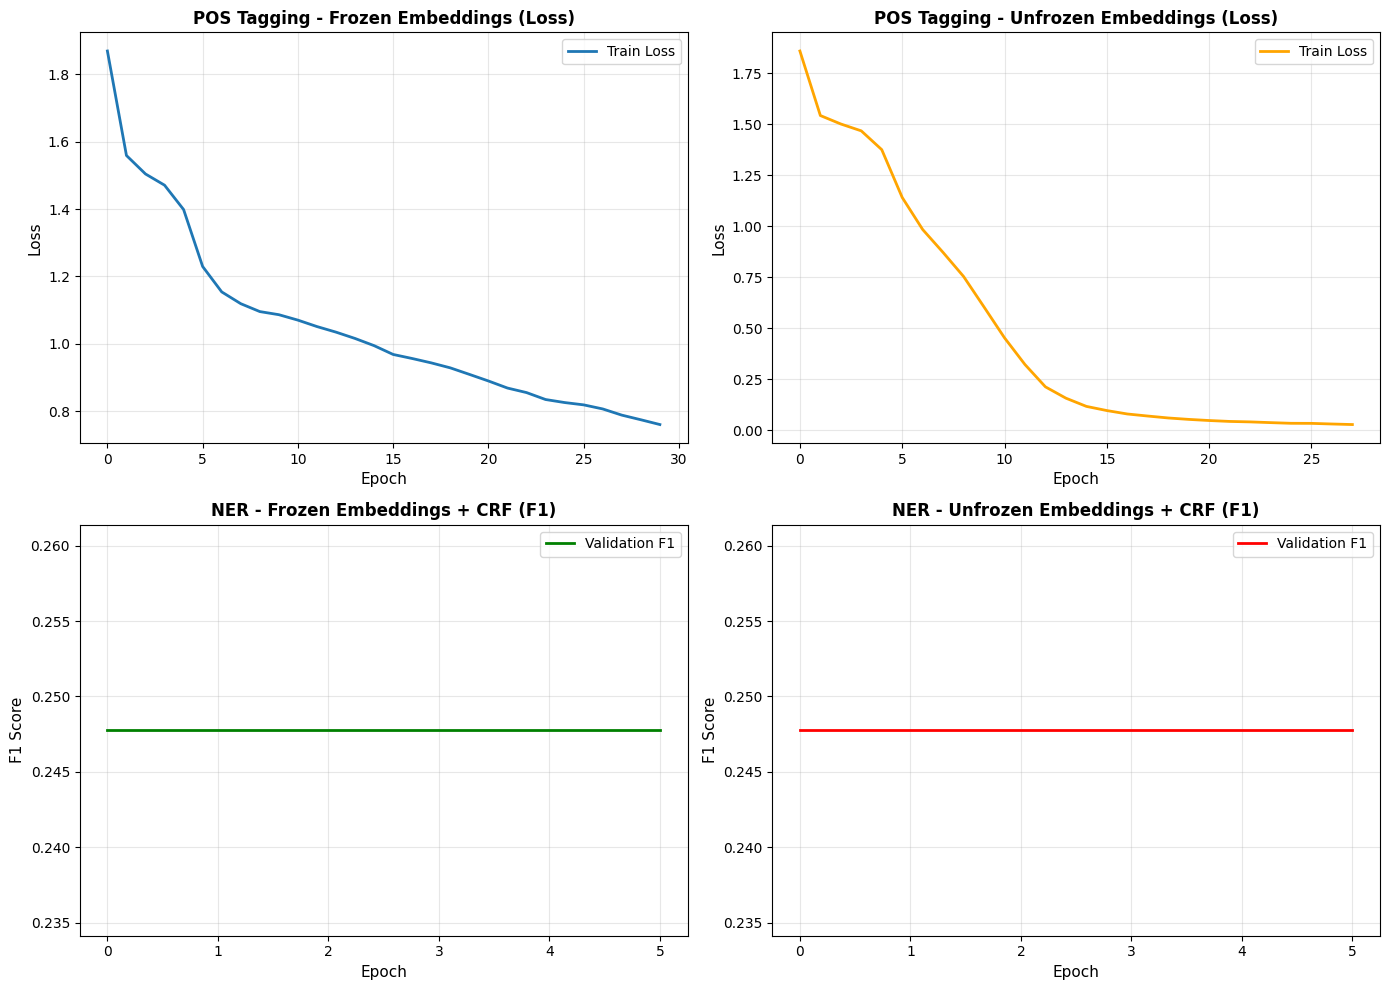


--------------------------------------------------------------------------------
Results Summary
--------------------------------------------------------------------------------
POS (Frozen):     Loss: 0.7609
POS (Unfrozen):   Loss: 0.0270
NER (Frozen):     F1: 0.2478
NER (Unfrozen):   F1: 0.2478


In [31]:
# ============================================================================
# PART 2: BILSTM EVALUATION AND VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print("Evaluation and Visualization")
print("="*80)

# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# POS - Frozen
axes[0, 0].plot(pos_train_loss_f, label='Train Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Loss', fontsize=11)
axes[0, 0].set_title('POS Tagging - Frozen Embeddings (Loss)', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# POS - Unfrozen
axes[0, 1].plot(pos_train_loss_u, label='Train Loss', linewidth=2, color='orange')
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Loss', fontsize=11)
axes[0, 1].set_title('POS Tagging - Unfrozen Embeddings (Loss)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# NER - Frozen
axes[1, 0].plot(ner_train_f1_f, label='Validation F1', linewidth=2, color='green')
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('F1 Score', fontsize=11)
axes[1, 0].set_title('NER - Frozen Embeddings + CRF (F1)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# NER - Unfrozen
axes[1, 1].plot(ner_train_f1_u, label='Validation F1', linewidth=2, color='red')
axes[1, 1].set_xlabel('Epoch', fontsize=11)
axes[1, 1].set_ylabel('F1 Score', fontsize=11)
axes[1, 1].set_title('NER - Unfrozen Embeddings + CRF (F1)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("models/bilstm_training_curves.png", dpi=100, bbox_inches='tight')
print("Saved: models/bilstm_training_curves.png")
plt.show()

print("\n" + "-"*80)
print("Results Summary")
print("-"*80)
print(f"POS (Frozen):     Loss: {pos_train_loss_f[-1]:.4f}")
print(f"POS (Unfrozen):   Loss: {pos_train_loss_u[-1]:.4f}")
print(f"NER (Frozen):     F1: {ner_train_f1_f[-1]:.4f}")
print(f"NER (Unfrozen):   F1: {ner_train_f1_u[-1]:.4f}")

---
## Part 3: Transformer for Topic Classification

In [32]:
# ============================================================================
# TRANSFORMER IMPLEMENTATION
# ============================================================================

class SimpleTransformer(nn.Module):
    """
    Simplified Transformer for Topic Classification
    Hyperparameters from spec: h=4 heads, d_model=128, AdamW η=5e-4
    """
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=4, dim_feedforward=512,
                 num_classes=5, max_len=256, dropout=0.1):
        super().__init__()

        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)

        # Positional encoding
        pe = torch.zeros(max_len + 1, d_model)
        position = torch.arange(0, max_len + 1).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 0:
            pe[:, 1::2] = torch.cos(position * div_term)
        else:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        self.register_buffer('pe', pe.unsqueeze(0))

        # CLS token
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

        # Transformer encoder layers
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True)
            for _ in range(num_layers)
        ])

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        batch_size = x.size(0)

        # Embeddings
        x = self.embedding(x) * math.sqrt(self.d_model)

        # Add CLS token
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        # Add positional encoding
        x = x + self.pe[:, :x.size(1), :]
        x = self.dropout(x)

        # Create attention mask
        if mask is not None:
            cls_mask = torch.ones(batch_size, 1, device=mask.device)
            mask = torch.cat([cls_mask, mask], dim=1)
            src_key_padding_mask = (mask == 0)
        else:
            src_key_padding_mask = None

        # Transformer layers
        for layer in self.layers:
            x = layer(x, src_key_padding_mask=src_key_padding_mask)

        # Use CLS token
        cls_output = x[:, 0]
        logits = self.classifier(cls_output)

        return logits


class TextDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len=256):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        words = text.split()[:self.max_len]
        indices = [self.word2idx.get(w, self.word2idx.get('<UNK>', 0)) for w in words]

        if len(indices) < self.max_len:
            indices += [0] * (self.max_len - len(indices))
        else:
            indices = indices[:self.max_len]

        return torch.tensor(indices), torch.tensor(label)


def collate_fn_transformer(batch):
    texts, labels = zip(*batch)
    texts = torch.stack(texts)
    labels = torch.stack(labels)
    mask = (texts != 0).float()
    return texts, labels, mask

print("Transformer classes loaded.")


Transformer classes loaded.



PART 3: TRANSFORMER FOR TOPIC CLASSIFICATION

Hyperparameters (from spec):
  h (nhead) = 4
  d_model = 128
  AdamW learning_rate = 5e-4

Loading data...
Category distribution: {0: 9592, 2: 484, 3: 504, 4: 216, 1: 372}
Train: 7817, Val: 1675, Test: 1676

Device: cuda

Training...
  Epoch 1, Batch 50/245, Loss: 0.6214
  Epoch 1, Batch 100/245, Loss: 0.6054
  Epoch 1, Batch 150/245, Loss: 0.5996
  Epoch 1, Batch 200/245, Loss: 0.5769
Epoch  1 | Train: 0.5587/0.8717 | Val: 0.5978/0.8507
  Epoch 2, Batch 50/245, Loss: 0.4746
  Epoch 2, Batch 100/245, Loss: 0.4631
  Epoch 2, Batch 150/245, Loss: 0.4354
  Epoch 2, Batch 200/245, Loss: 0.3990
Epoch  2 | Train: 0.3872/0.9083 | Val: 0.3739/0.8949
  Epoch 3, Batch 50/245, Loss: 0.2551
  Epoch 3, Batch 100/245, Loss: 0.2414
  Epoch 3, Batch 150/245, Loss: 0.2274
  Epoch 3, Batch 200/245, Loss: 0.2378
Epoch  3 | Train: 0.2371/0.9516 | Val: 0.2828/0.9433
  Epoch 4, Batch 50/245, Loss: 0.1902
  Epoch 4, Batch 100/245, Loss: 0.2080
  Epoch 4, Batch 1

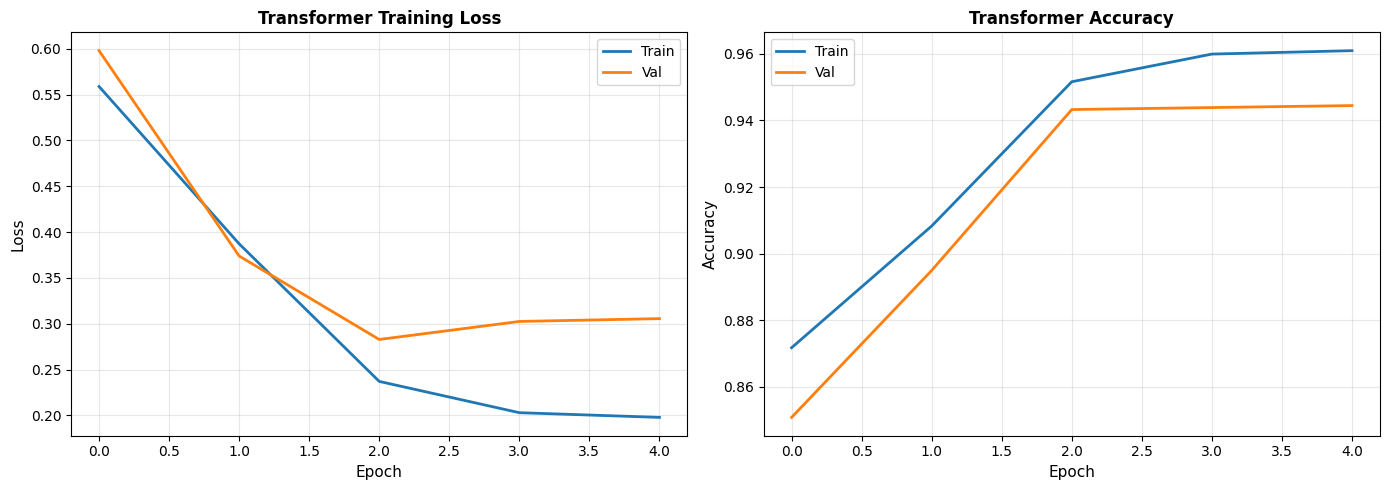

In [33]:
# ============================================================================
# PART 3: TRANSFORMER TRAINING
# ============================================================================

print("\n" + "="*80)
print("PART 3: TRANSFORMER FOR TOPIC CLASSIFICATION")
print("="*80)
print("\nHyperparameters (from spec):")
print("  h (nhead) = 4")
print("  d_model = 128")
print("  AdamW learning_rate = 5e-4")
print()

# Load data
print("Loading data...")
with open("data/cleaned.txt", 'r', encoding='utf-8') as f:
    documents = [line.strip() for line in f if line.strip()]

with open("embeddings/word2idx.json", 'r', encoding='utf-8') as f:
    word2idx = json.load(f)

# Assign categories based on keywords
categories = []
for doc in documents:
    doc_lower = doc.lower()

    if any(word in doc_lower for word in ['کرکٹ', 'میچ', 'ٹیم', 'کھلاڑی', 'فٹبال']):
        categories.append(1)  # Sports
    elif any(word in doc_lower for word in ['معیشت', 'تجارت', 'بینک', 'روپے', 'ڈالر']):
        categories.append(2)  # Economy
    elif any(word in doc_lower for word in ['امریکا', 'چین', 'برطانیہ', 'بین', 'الاقوامی']):
        categories.append(3)  # International
    elif any(word in doc_lower for word in ['صحت', 'ہسپتال', 'بیماری', 'تعلیم', 'سیلاب']):
        categories.append(4)  # Health
    else:
        categories.append(0)  # Politics

from collections import Counter
dist = Counter(categories)
print(f"Category distribution: {dict(dist)}")

# Split: 70/15/15
n = len(documents)
train_end = int(n * 0.7)
val_end = train_end + int(n * 0.15)

train_ds = TextDataset(documents[:train_end], categories[:train_end], word2idx)
val_ds = TextDataset(documents[train_end:val_end], categories[train_end:val_end], word2idx)
test_ds = TextDataset(documents[val_end:], categories[val_end:], word2idx)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}\n")

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_fn_transformer)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, collate_fn=collate_fn_transformer)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, collate_fn=collate_fn_transformer)

# Create model with spec hyperparameters
model = SimpleTransformer(
    vocab_size=len(word2idx),
    d_model=128,        # from spec
    nhead=4,            # h=4 from spec
    num_layers=4,
    dim_feedforward=512,
    num_classes=5,
    dropout=0.1
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}\n")
model.to(device)

# Use AdamW with η=5e-4 from spec
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

# Training
train_losses, val_losses, train_accs, val_accs = [], [], [], []

print("Training...")
for epoch in range(5):  # 5 epochs
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch_idx, (texts, labels, mask) in enumerate(train_loader):
        texts, labels, mask = texts.to(device), labels.to(device), mask.to(device)

        optimizer.zero_grad()
        logits = model(texts, mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)

        if (batch_idx + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}, Batch {batch_idx+1}/{len(train_loader)}, Loss: {total_loss/(batch_idx+1):.4f}")

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Val
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for texts, labels, mask in val_loader:
            texts, labels, mask = texts.to(device), labels.to(device), mask.to(device)
            logits = model(texts, mask)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:2d} | Train: {train_loss:.4f}/{train_acc:.4f} | Val: {val_loss:.4f}/{val_acc:.4f}")

# Save
torch.save(model.state_dict(), "models/transformer_cls.pt")
print("\nSaved: models/transformer_cls.pt")

# Plot
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train', linewidth=2)
plt.plot(val_losses, label='Val', linewidth=2)
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Loss', fontsize=11)
plt.title('Transformer Training Loss', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train', linewidth=2)
plt.plot(val_accs, label='Val', linewidth=2)
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.title('Transformer Accuracy', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("models/transformer_curves.png", dpi=100, bbox_inches='tight')
print("Saved: models/transformer_curves.png")
plt.show()


Test Evaluation

Transformer Test Results:
  Accuracy: 0.9415
  Macro F1: 0.8128

Classification Report:
              precision    recall  f1-score   support

    Politics     0.9429    1.0000    0.9706      1419
      Sports     1.0000    0.6875    0.8148        16
     Economy     1.0000    0.5207    0.6848       121
        Intl     0.8810    0.6981    0.7789       106
      Health     0.8462    0.7857    0.8148        14

    accuracy                         0.9415      1676
   macro avg     0.9340    0.7384    0.8128      1676
weighted avg     0.9428    0.9415    0.9350      1676


Saved: models/transformer_confusion.png


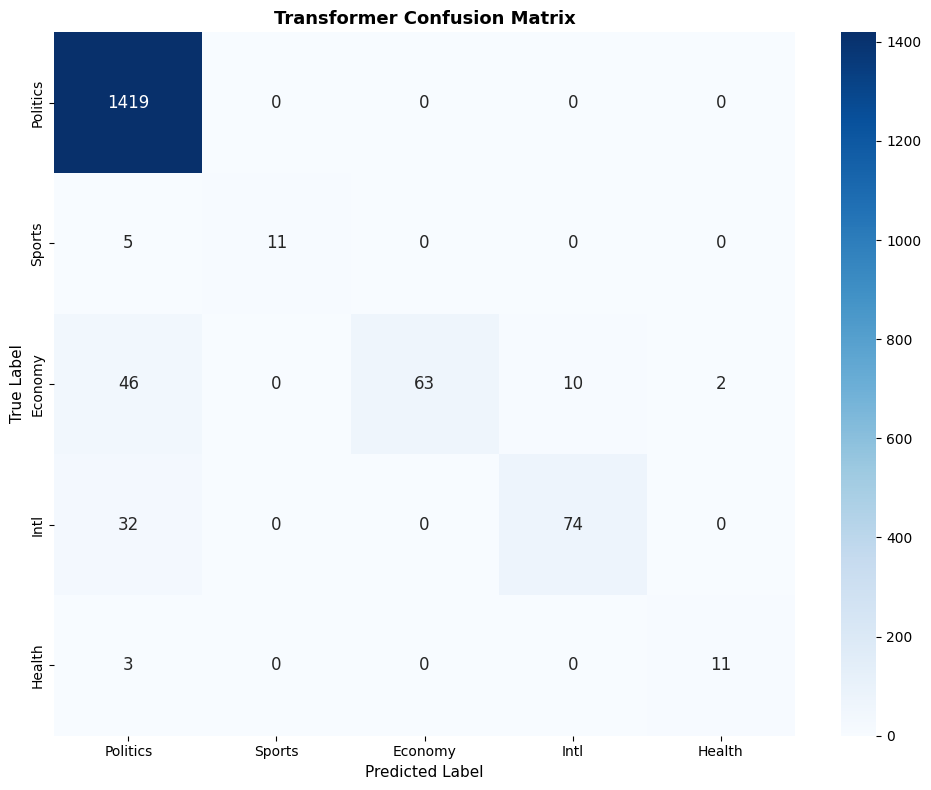

In [34]:
# ============================================================================
# PART 3: TEST EVALUATION AND ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("Test Evaluation")
print("="*80)

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for texts, labels, mask in test_loader:
        texts, labels, mask = texts.to(device), labels.to(device), mask.to(device)
        logits = model(texts, mask)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='macro')

print(f"\nTransformer Test Results:")
print(f"  Accuracy: {acc:.4f}")
print(f"  Macro F1: {f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(all_labels, all_preds,
                           target_names=['Politics', 'Sports', 'Economy', 'Intl', 'Health'],
                           digits=4))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Politics', 'Sports', 'Economy', 'Intl', 'Health'],
            yticklabels=['Politics', 'Sports', 'Economy', 'Intl', 'Health'],
            annot_kws={'size': 12})
plt.title('Transformer Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.savefig("models/transformer_confusion.png", dpi=100, bbox_inches='tight')
print("\nSaved: models/transformer_confusion.png")
plt.show()